In [1]:
import sys
from pathlib import Path

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "src" / "cnn_model.py").is_file():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not find the project root (folder that contains src/)")

from src.preprocessing import get_dataloaders
from src.cnn_model import CNN

loaders = get_dataloaders(batch_size=32, image_size=224)  # RGB
# loaders = get_dataloaders(use_ela=True)                # CNN + ELA

In [10]:
model = CNN(input_channel=3, output_channels=[128, 256, 512])
n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")


Number of parameters: 1481730


In [11]:
history = model.fit(loaders["train"], loaders["val"])

Epoch 1/10, Train Loss: 0.6655, Train Accuracy: 0.6119, Val Loss: 0.6297, Val Accuracy: 0.6550
Epoch 2/10, Train Loss: 0.6428, Train Accuracy: 0.6356, Val Loss: 0.6187, Val Accuracy: 0.6542
Epoch 3/10, Train Loss: 0.6206, Train Accuracy: 0.6619, Val Loss: 0.6061, Val Accuracy: 0.6550
Epoch 4/10, Train Loss: 0.6155, Train Accuracy: 0.6658, Val Loss: 0.6038, Val Accuracy: 0.6899
Epoch 5/10, Train Loss: 0.6048, Train Accuracy: 0.6829, Val Loss: 0.5968, Val Accuracy: 0.6987
Epoch 6/10, Train Loss: 0.5976, Train Accuracy: 0.6897, Val Loss: 0.6320, Val Accuracy: 0.6281
Epoch 7/10, Train Loss: 0.5852, Train Accuracy: 0.7027, Val Loss: 0.5984, Val Accuracy: 0.6416
Epoch 8/10, Train Loss: 0.5706, Train Accuracy: 0.7126, Val Loss: 0.5778, Val Accuracy: 0.6685
Epoch 9/10, Train Loss: 0.5644, Train Accuracy: 0.7199, Val Loss: 1.3375, Val Accuracy: 0.5964
Epoch 10/10, Train Loss: 0.5406, Train Accuracy: 0.7390, Val Loss: 0.5653, Val Accuracy: 0.7320


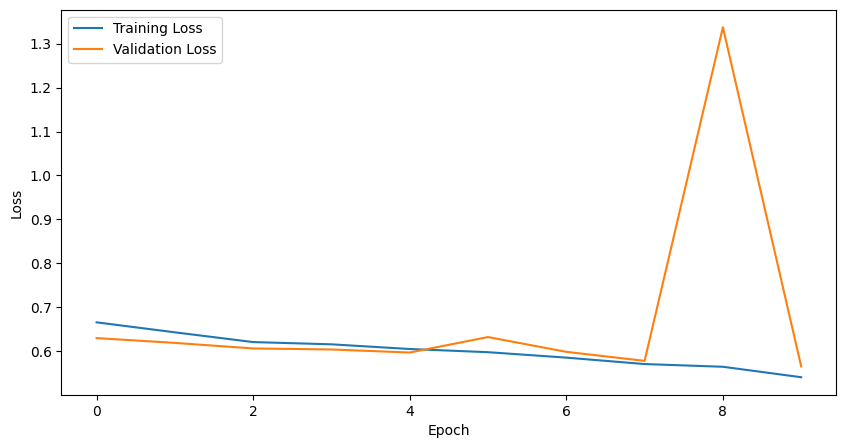

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
preds = model.predict(next(iter(loaders["test"]))[0])
preds = preds.to('cpu')

In [16]:
# calculate the accuracy
accuracy = (preds == next(iter(loaders["test"]))[1]).sum().item() / len(next(iter(loaders["test"]))[1])
print(f"Accuracy: {accuracy}")

Accuracy: 0.53125
